PREDICTOR DEL GÉNERO MUSICAL DE UNA CANCIÓN USANDO MACHINE LEARNING


Obtención de Datos

In [ ]:
# Conexión con Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Descomprimimos los conjuntos de datos

print("Descomprimiendo en el disco local de la sesión...")
!unzip -q "/content/drive/MyDrive/ProyectoIA/data/fma_small.zip" -d "/content/drive/MyDrive/ProyectoIA/data/fma_data"

print("¡Hecho! Ahora los archivos están en /content/fma_data/fma_small")

Descomprimiendo en el disco local de la sesión...
¡Hecho! Ahora los archivos están en /content/fma_data/fma_small


Exloración de los Metadatos

In [ ]:
import pandas as pd

tracks = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv", header=[0,1], index_col=0)
echonest = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/echonest.csv", header=[0,1,2], index_col=0)
genres = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/genres.csv")
features = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/features.csv", header = [0,1,2], index_col = 0)

In [ ]:
tracks.head()

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [ ]:
echonest.head()

echonest                                                    \
         audio_features                                                     
           acousticness danceability    energy instrumentalness  liveness   
track_id                                                                    
2              0.416675     0.675894  0.634476         0.010628  0.177647   
3              0.374408     0.528643  0.817461         0.001851  0.105880   
5              0.043567     0.745566  0.701470         0.000697  0.373143   
10             0.951670     0.658179  0.924525         0.965427  0.115474   
134            0.452217     0.513238  0.560410         0.019443  0.096567   

                                                                        ...  \
                                           metadata                     ...   
         speechiness    tempo   valence  album_date         album_name  ...   
track_id                                                                ...   
2           0.159310  165.922  0.576661         NaN                NaN  ...   
3           0.461818  126.957  0.269240         NaN                NaN  ...   
5           0.124595  100.260  0.621661         NaN                NaN  ...   
10          0.032985  111.562  0.963590  2008-03-11  Constant Hitmaker  ...   
134         0.525519  114.290  0.894072         NaN                NaN  ...   

                                                                              \
         temporal_features                                                     
                       214        215       216       217       218      219   
track_id                                                                       
2                -1.992303   6.805694  0.233070  0.192880  0.027455  0.06408   
3                -1.582331   8.889308  0.258464  0.220905  0.081368  0.06413   
5                -2.288358  11.527109  0.256821  0.237820  0.060122  0.06014   
10               -3.662988  21.508228  0.283352  0.267070  0.125704  0.08082   
134              -1.452696   2.356398  0.234686  0.199550  0.149332  0.06440   

                                                     
                                                     
               220       221        222         223  
track_id                                             
2          3.67696   3.61288  13.316690  262.929749  
3          6.08277   6.01864  16.673548  325.581085  
5          5.92649   5.86635  16.013849  356.755737  
10         8.41401   8.33319  21.317064  483.403809  
134       11.26707  11.20267  26.454180  751.147705  

[5 rows x 249 columns]

In [ ]:
echonest.columns

MultiIndex([('echonest',    'audio_features',     'acousticness'),
            ('echonest',    'audio_features',     'danceability'),
            ('echonest',    'audio_features',           'energy'),
            ('echonest',    'audio_features', 'instrumentalness'),
            ('echonest',    'audio_features',         'liveness'),
            ('echonest',    'audio_features',      'speechiness'),
            ('echonest',    'audio_features',            'tempo'),
            ('echonest',    'audio_features',          'valence'),
            ('echonest',          'metadata',       'album_date'),
            ('echonest',          'metadata',       'album_name'),
            ...
            ('echonest', 'temporal_features',              '214'),
            ('echonest', 'temporal_features',              '215'),
            ('echonest', 'temporal_features',              '216'),
            ('echonest', 'temporal_features',              '217'),
            ('echonest', 'temporal_features', 

In [ ]:
genres.head()

,genre_id,#tracks,parent,title,top_level
0,1,8693,38,Avant-Garde,38
1,2,5271,0,International,2
2,3,1752,0,Blues,3
3,4,4126,0,Jazz,4
4,5,4106,0,Classical,5


In [ ]:
features.head()

feature    chroma_cens                                                    \
statistics    kurtosis                                                     
number              01        02        03        04        05        06   
track_id                                                                   
2             7.180653  5.230309  0.249321  1.347620  1.482478  0.531371   
3             1.888963  0.760539  0.345297  2.295201  1.654031  0.067592   
5             0.527563 -0.077654 -0.279610  0.685883  1.937570  0.880839   
10            3.702245 -0.291193  2.196742 -0.234449  1.367364  0.998411   
20           -0.193837 -0.198527  0.201546  0.258556  0.775204  0.084794   

feature                                             ...   tonnetz            \
statistics                                          ...       std             
number            07        08        09        10  ...        04        05   
track_id                                            ...                       
2           1.481593  2.691455  0.866868  1.341231  ...  0.054125  0.012226   
3           1.366848  1.054094  0.108103  0.619185  ...  0.063831  0.014212   
5          -0.923192 -0.927232  0.666617  1.038546  ...  0.040730  0.012691   
10          1.770694  1.604566  0.521217  1.982386  ...  0.074358  0.017952   
20         -0.289294 -0.816410  0.043851 -0.804761  ...  0.095003  0.022492   

feature                     zcr                                          \
statistics             kurtosis       max      mean    median       min   
number            06         01        01        01        01        01   
track_id                                                                  
2           0.012111   5.758890  0.459473  0.085629  0.071289  0.000000   
3           0.017740   2.824694  0.466309  0.084578  0.063965  0.000000   
5           0.014759   6.808415  0.375000  0.053114  0.041504  0.000000   
10          0.013921  21.434212  0.452148  0.077515  0.071777  0.000000   
20          0.021355  16.669037  0.469727  0.047225  0.040039  0.000977   

feature                         
statistics      skew       std  
number            01        01  
track_id                        
2           2.089872  0.061448  
3           1.716724  0.069330  
5           2.193303  0.044861  
10          3.542325  0.040800  
20          3.189831  0.030993  

[5 rows x 518 columns]

Transformación de datos

In [ ]:
# Obtenemos la versión reducida de tracks.csv

tracks_small = tracks[tracks[("set","subset")] == "small"]
ids_small = tracks_small.index
tracks_small.shape

(8000, 52)

In [ ]:
tracks_small[('track', 'genre_top')].value_counts()

,count
"(track, genre_top)",
Hip-Hop,1000
Pop,1000
Folk,1000
Experimental,1000
Rock,1000
International,1000
Electronic,1000
Instrumental,1000


In [ ]:
tracks_small.columns

MultiIndex([( 'album',          'comments'),
            ( 'album',      'date_created'),
            ( 'album',     'date_released'),
            ( 'album',          'engineer'),
            ( 'album',         'favorites'),
            ( 'album',                'id'),
            ( 'album',       'information'),
            ( 'album',           'listens'),
            ( 'album',          'producer'),
            ( 'album',              'tags'),
            ( 'album',             'title'),
            ( 'album',            'tracks'),
            ( 'album',              'type'),
            ('artist', 'active_year_begin'),
            ('artist',   'active_year_end'),
            ('artist', 'associated_labels'),
            ('artist',               'bio'),
            ('artist',          'comments'),
            ('artist',      'date_created'),
            ('artist',         'favorites'),
            ('artist',                'id'),
            ('artist',          'latitude'),
          

In [ ]:
# Obtenemos la versión reducida de features.csv

features_small = features.loc[ids_small]
features_small.shape

(8000, 518)

In [ ]:
features_small.columns.tolist()

[('chroma_cens', 'kurtosis', '01'),
 ('chroma_cens', 'kurtosis', '02'),
 ('chroma_cens', 'kurtosis', '03'),
 ('chroma_cens', 'kurtosis', '04'),
 ('chroma_cens', 'kurtosis', '05'),
 ('chroma_cens', 'kurtosis', '06'),
 ('chroma_cens', 'kurtosis', '07'),
 ('chroma_cens', 'kurtosis', '08'),
 ('chroma_cens', 'kurtosis', '09'),
 ('chroma_cens', 'kurtosis', '10'),
 ('chroma_cens', 'kurtosis', '11'),
 ('chroma_cens', 'kurtosis', '12'),
 ('chroma_cens', 'max', '01'),
 ('chroma_cens', 'max', '02'),
 ('chroma_cens', 'max', '03'),
 ('chroma_cens', 'max', '04'),
 ('chroma_cens', 'max', '05'),
 ('chroma_cens', 'max', '06'),
 ('chroma_cens', 'max', '07'),
 ('chroma_cens', 'max', '08'),
 ('chroma_cens', 'max', '09'),
 ('chroma_cens', 'max', '10'),
 ('chroma_cens', 'max', '11'),
 ('chroma_cens', 'max', '12'),
 ('chroma_cens', 'mean', '01'),
 ('chroma_cens', 'mean', '02'),
 ('chroma_cens', 'mean', '03'),
 ('chroma_cens', 'mean', '04'),
 ('chroma_cens', 'mean', '05'),
 ('chroma_cens', 'mean', '06'),
 ('c

In [ ]:
# Obtenemos la versión reducida de features.csv

common_ids = echonest.index.intersection(ids_small)
echonest_small = echonest.loc[common_ids]
echonest_small.shape

(1294, 249)

Ordenación de Datos


In [ ]:
# Ordenamos las canciones por escuchas

tracks_small = tracks_small.sort_values(by=('track', 'listens'), ascending=False)

Obtenemos la Variable Objetivo

In [ ]:
objetivo = tracks_small[[("track", "genre_top")]]
objetivo.shape

(8000, 1)

In [ ]:
objetivo.head()

,track
,genre_top
track_id,
2,Hip-Hop
5,Hip-Hop
10,Pop
140,Folk
141,Folk


In [ ]:
objetivo.isna().sum()

,,0
track,genre_top,0


Limpieza de Datos

In [ ]:
import pandas as pd

# Seleccionamos las columnas más importantes de tracks_small
columns_to_keep = [
    ('track', 'title'),
    ('album', 'title'),
    ('artist', 'name'),
    ('track', 'genre_top'),
    ('track', 'duration'),
    ('track', 'listens'),
    ('set', 'split'),
    ('set', 'subset')
]

# Aplicamos el filtro de columnas

tracks_small_clean = tracks_small[columns_to_keep].copy()

tracks_small_clean.columns = ['_'.join(col).strip() for col in tracks_small_clean.columns]

print(f"Forma final del dataset: {tracks_small_clean.shape}")
print(tracks_small_clean.head())

Forma final del dataset: (8000, 8)
                 track_title            album_title  \
track_id                                              
2                       Food   AWOL - A Way Of Life   
5                 This World   AWOL - A Way Of Life   
10                   Freeway      Constant Hitmaker   
140       Queen Of The Wires         The Blind Spot   
141                     Ohio  Every Man For Himself   

                              artist_name track_genre_top  track_duration  \
track_id                                                                    
2                                    AWOL         Hip-Hop             168   
5                                    AWOL         Hip-Hop             206   
10                              Kurt Vile             Pop             161   
140       Alec K. Redfearn & the Eyesores            Folk             253   
141       Alec K. Redfearn & the Eyesores            Folk             182   

          track_listens set_split set_s

In [ ]:
tracks_IA = tracks_small_clean
tracks_IA.head()

,track_title,album_title,artist_name,track_genre_top,track_duration,track_listens,set_split,set_subset
track_id,,,,,,,,
2,Food,AWOL - A Way Of Life,AWOL,Hip-Hop,168,1293,training,small
5,This World,AWOL - A Way Of Life,AWOL,Hip-Hop,206,1151,training,small
10,Freeway,Constant Hitmaker,Kurt Vile,Pop,161,50135,training,small
140,Queen Of The Wires,The Blind Spot,Alec K. Redfearn & the Eyesores,Folk,253,1299,training,small
141,Ohio,Every Man For Himself,Alec K. Redfearn & the Eyesores,Folk,182,725,training,small


Obtenemos los datos echonest, que no vamos a usar para los modelos al no estar presentes para todas las canciones, pero sí vamos a usarlos para la visualización

In [ ]:
echo = echonest

# Extraemos solo las "audio_features" (las 8 métricas de sonido)
echo_features = echo[('echonest', 'audio_features')].copy()

# Les ponemos nombres simples (ej: 'echo_energy')
echo_features.columns = [f'echo_{col}' for col in echo_features.columns.get_level_values(0)]

# Juntamos todo en un solo dataframe
echonest_IA = tracks_small_clean.merge(echo_features, left_index=True, right_index=True, how='inner')

print(f"Forma final del dataset: {echonest_IA.shape}")
print(echonest_IA.head())

Forma final del dataset: (1294, 16)
                 track_title            album_title  \
track_id                                              
2                       Food   AWOL - A Way Of Life   
5                 This World   AWOL - A Way Of Life   
10                   Freeway      Constant Hitmaker   
140       Queen Of The Wires         The Blind Spot   
141                     Ohio  Every Man For Himself   

                              artist_name track_genre_top  track_duration  \
track_id                                                                    
2                                    AWOL         Hip-Hop             168   
5                                    AWOL         Hip-Hop             206   
10                              Kurt Vile             Pop             161   
140       Alec K. Redfearn & the Eyesores            Folk             253   
141       Alec K. Redfearn & the Eyesores            Folk             182   

          track_listens set_split set_

In [ ]:
echonest_IA.head()

,track_title,album_title,artist_name,track_genre_top,track_duration,track_listens,set_split,set_subset,echo_acousticness,echo_danceability,echo_energy,echo_instrumentalness,echo_liveness,echo_speechiness,echo_tempo,echo_valence
track_id,,,,,,,,,,,,,,,,
2,Food,AWOL - A Way Of Life,AWOL,Hip-Hop,168,1293,training,small,0.416675,0.675894,0.634476,0.010628,0.177647,0.159310,165.922,0.576661
5,This World,AWOL - A Way Of Life,AWOL,Hip-Hop,206,1151,training,small,0.043567,0.745566,0.701470,0.000697,0.373143,0.124595,100.260,0.621661
10,Freeway,Constant Hitmaker,Kurt Vile,Pop,161,50135,training,small,0.951670,0.658179,0.924525,0.965427,0.115474,0.032985,111.562,0.963590
140,Queen Of The Wires,The Blind Spot,Alec K. Redfearn & the Eyesores,Folk,253,1299,training,small,0.376312,0.734079,0.265685,0.669581,0.085995,0.039068,107.952,0.609991
141,Ohio,Every Man For Himself,Alec K. Redfearn & the Eyesores,Folk,182,725,training,small,0.963657,0.435933,0.075632,0.345493,0.105686,0.026658,33.477,0.163950


Análisis Descriptivo y Visualización

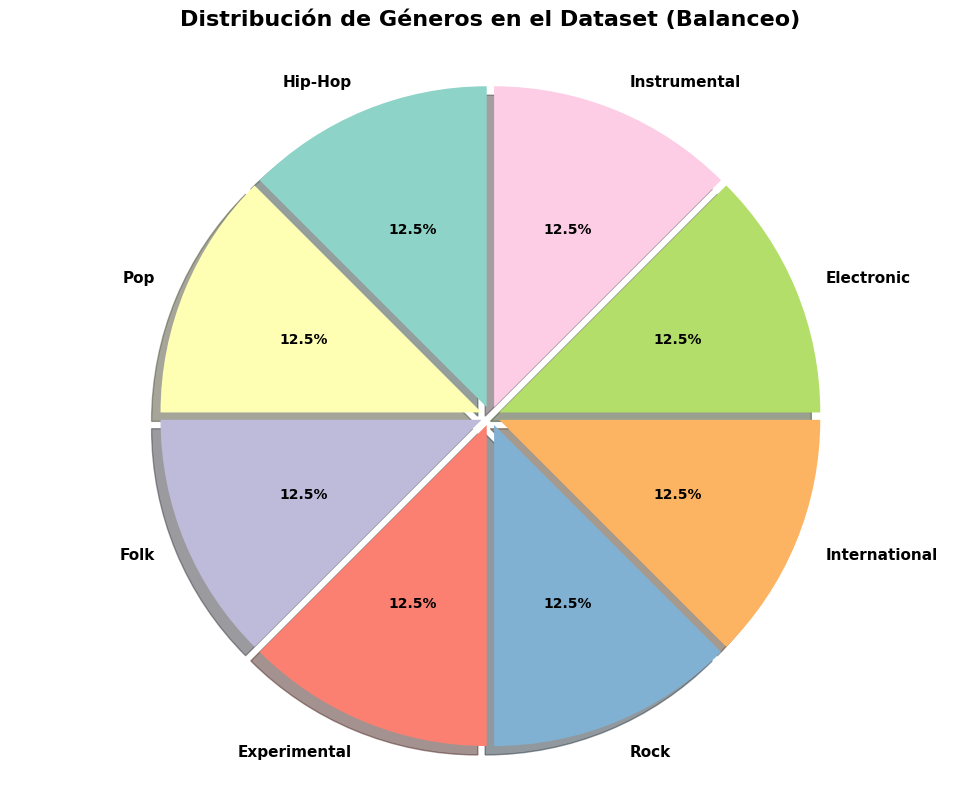

In [ ]:
import matplotlib.pyplot as plt

conteo_generos = tracks_small[('track', 'genre_top')].value_counts()

plt.figure(figsize=(10, 8), facecolor='white')

colores = plt.cm.Set3(range(len(conteo_generos)))

# Creamos el gráfico de pastel
patches, texts, autotexts = plt.pie(
    conteo_generos,
    labels=conteo_generos.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colores,
    shadow=True,
    explode=[0.03] * len(conteo_generos)
)
for text in texts:
    text.set_fontsize(11)
    text.set_weight('bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

plt.title('Distribución de Géneros en el Dataset (Balanceo)', fontsize=16, pad=20, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2308/886361514.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_plot, x='Género', y='Brillo (Spectral Centroid)', palette='Set3')
/tmp/ipykernel_2308/886361514.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_plot, x='Género', y='Energía (RMSE)', palette='Pastel2')


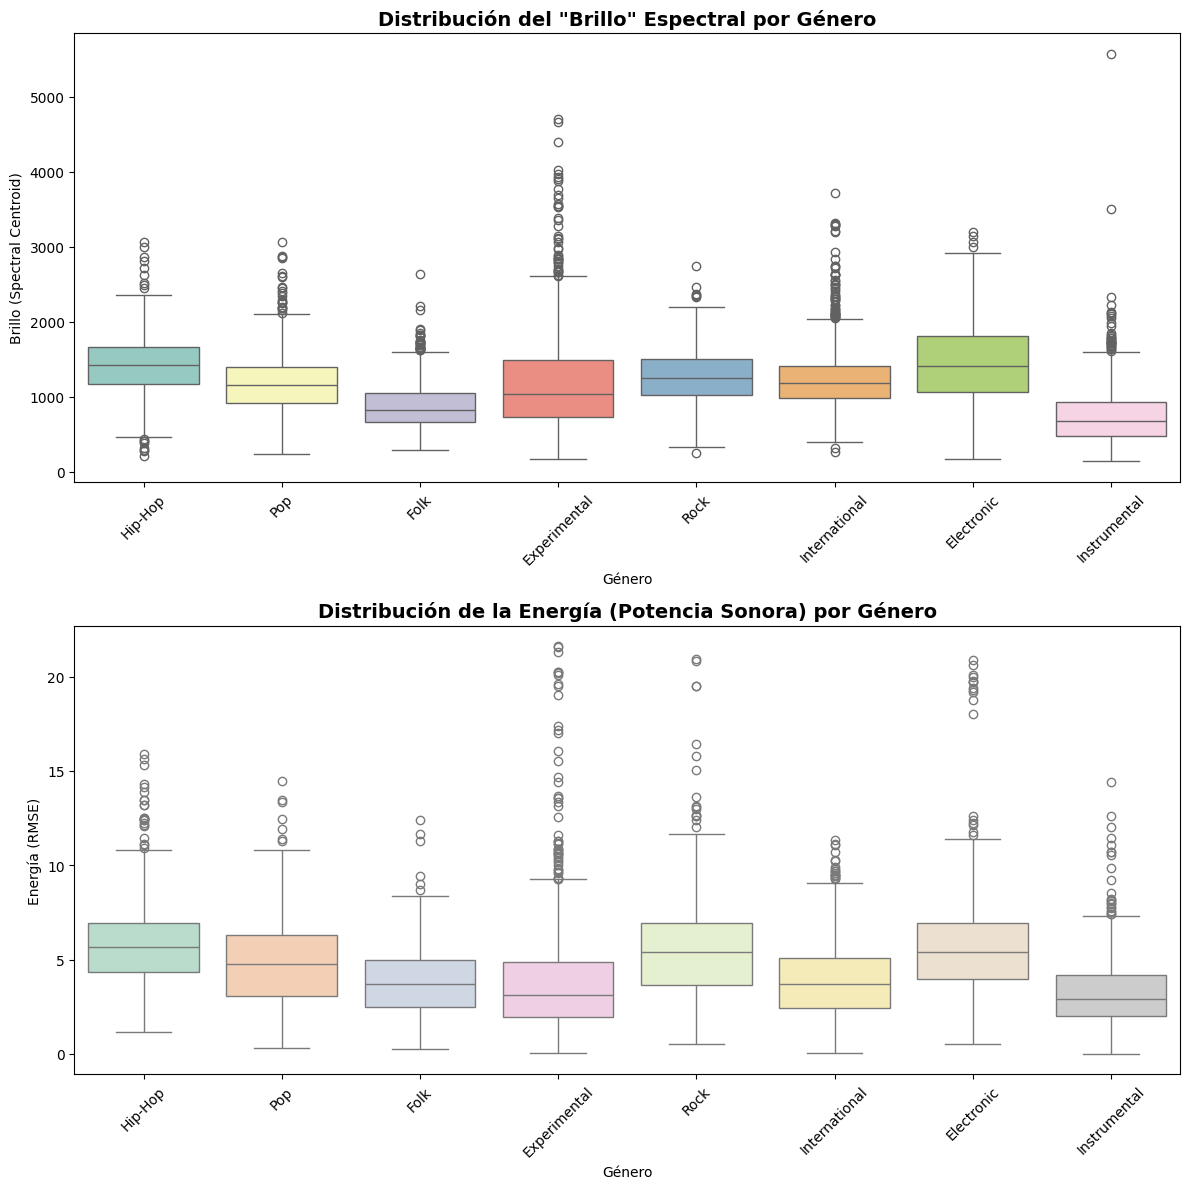

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

tracks_small = tracks[tracks[('set', 'subset')] == 'small']
generos = tracks_small[('track', 'genre_top')]

df_plot = pd.DataFrame({
    'Género': generos,
    'Brillo (Spectral Centroid)': features.loc[generos.index, ('spectral_centroid', 'mean', '01')],
    'Energía (RMSE)': features.loc[generos.index, ('rmse', 'mean', '01')]
})

# Dibujar los Boxplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(ax=axes[0], data=df_plot, x='Género', y='Brillo (Spectral Centroid)', palette='Set3')
axes[0].set_title('Distribución del "Brillo" Espectral por Género', fontsize=14, weight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(ax=axes[1], data=df_plot, x='Género', y='Energía (RMSE)', palette='Pastel2')
axes[1].set_title('Distribución de la Energía (Potencia Sonora) por Género', fontsize=14, weight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

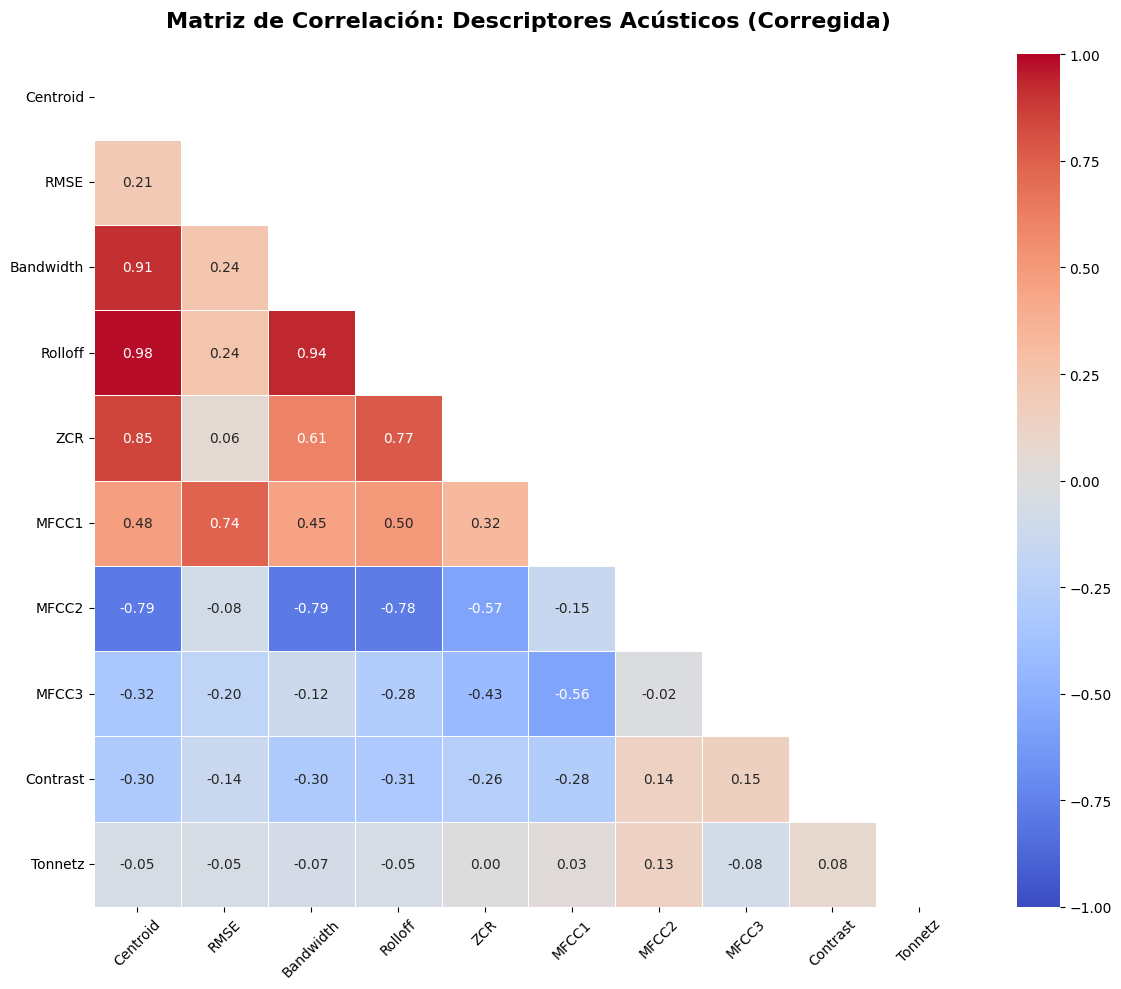

In [ ]:
# MATRIZ DE CORRELACIÓN

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


subset_features = [
    ('spectral_centroid', 'mean', '01'),
    ('rmse', 'mean', '01'),
    ('spectral_bandwidth', 'mean', '01'),
    ('spectral_rolloff', 'mean', '01'),
    ('zcr', 'mean', '01'),
    ('mfcc', 'mean', '01'),
    ('mfcc', 'mean', '02'),
    ('mfcc', 'mean', '03'),
    ('spectral_contrast', 'mean', '01'),
    ('tonnetz', 'mean', '01')
]


try:
    df_corr = features.loc[tracks_small.index, subset_features]
except KeyError:
    subset_features_alt = [(c[0], c[1], c[2].replace('0', '') if c[2].startswith('0') else c[2]) for c in subset_features]
    df_corr = features.loc[tracks_small.index, subset_features_alt]

df_corr.columns = ['Centroid', 'RMSE', 'Bandwidth', 'Rolloff', 'ZCR', 'MFCC1', 'MFCC2', 'MFCC3', 'Contrast', 'Tonnetz']

matriz = df_corr.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matriz, dtype=bool))

sns.heatmap(
    matriz,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5
)

plt.title('Matriz de Correlación: Descriptores Acústicos (Corregida)', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🧊 Calculando el Análisis de Componentes Principales (PCA)...


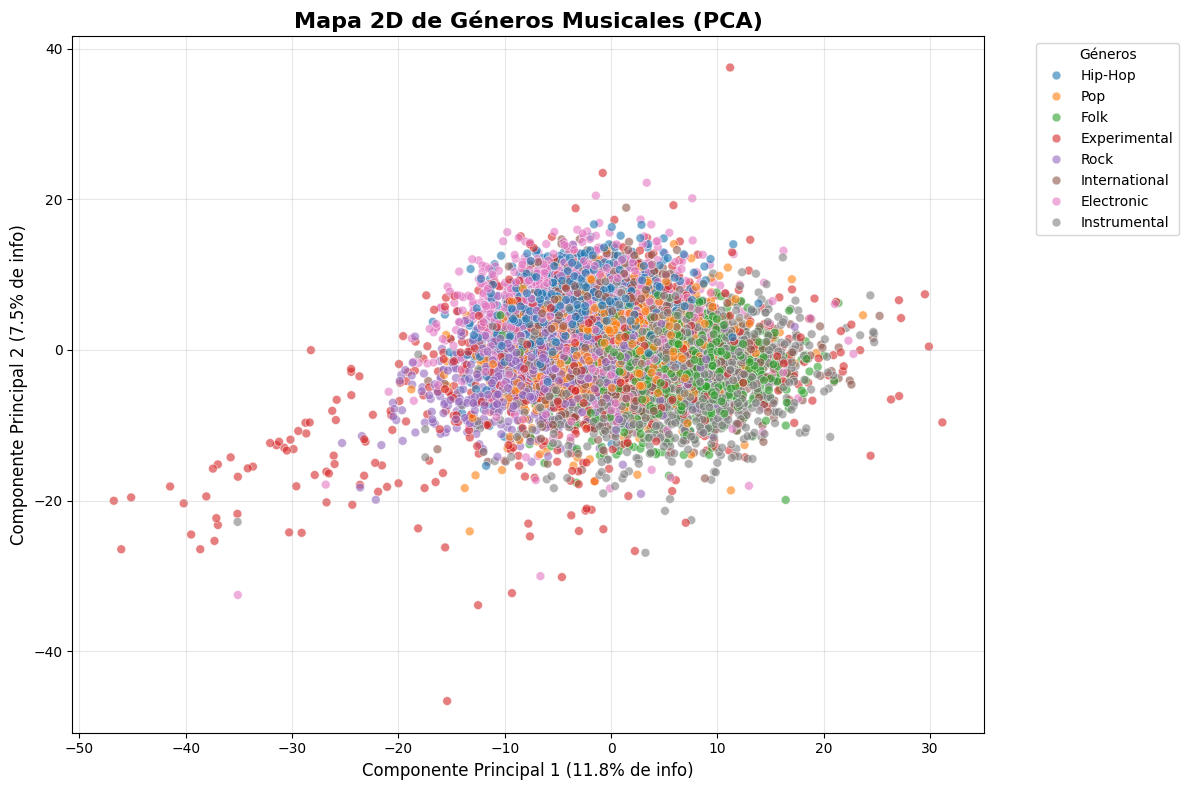

✅ ¡Hecho! El gráfico muestra cómo se agrupan las 8000 canciones basándose en su firma acústica.


In [ ]:
# COMPONENTES PRINCIPALES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("🧊 Calculando el Análisis de Componentes Principales (PCA)...")

X_pca = features.loc[tracks_small.index]
y_pca = tracks_small[('track', 'genre_top')]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = componentes, columns = ['PC1', 'PC2'])
df_pca['Género'] = y_pca.values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Género',
    data=df_pca,
    palette='tab10',
    alpha=0.6,
    s=40
)

var_exp = pca.explained_variance_ratio_

plt.title('Mapa 2D de Géneros Musicales (PCA)', fontsize=16, weight='bold')
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}% de info)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}% de info)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Géneros')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ ¡Hecho! El gráfico muestra cómo se agrupan las {len(df_pca)} canciones basándose en su firma acústica.")

In [ ]:
Más transformación de datos:

In [ ]:
import pandas as pd

generos = tracks['track']['genre_top']

audio_features = echonest['echonest']['audio_features']

datos_combinados = audio_features.join(generos).dropna()

datos_combinados.rename(columns={'genre_top': 'genero_objetivo'}, inplace=True)

print(f"¡Listo! Tabla creada con {datos_combinados.shape[0]} canciones.")

¡Listo! Tabla creada con 9355 canciones.


/tmp/ipykernel_2308/207986325.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stats1 = np.concatenate((stats1, [stats1[0]]))
/tmp/ipykernel_2308/207986325.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  stats2 = np.concatenate((stats2, [stats2[0]]))


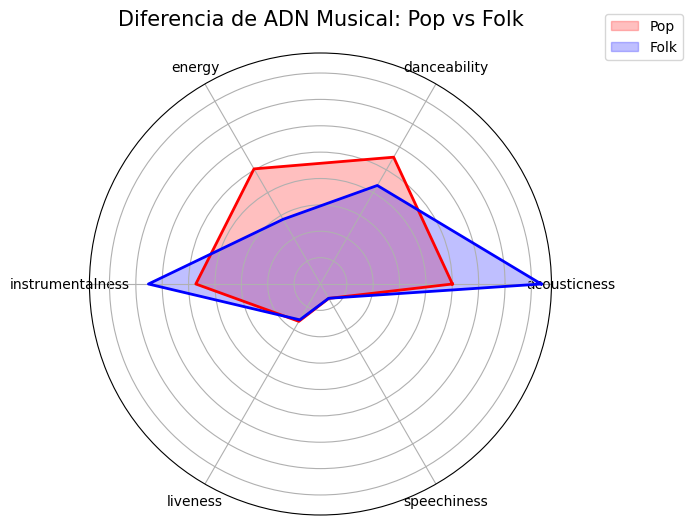

In [ ]:
# RADAR DE PERSONALIDAD

import matplotlib.pyplot as plt
import numpy as np

gen1 = 'Pop'
gen2 = 'Folk'

features_radar = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness']

stats1 = datos_combinados[datos_combinados['genero_objetivo'] == gen1][features_radar].mean()
stats2 = datos_combinados[datos_combinados['genero_objetivo'] == gen2][features_radar].mean()

angles = np.linspace(0, 2*np.pi, len(features_radar), endpoint=False).tolist()
stats1 = np.concatenate((stats1, [stats1[0]]))
stats2 = np.concatenate((stats2, [stats2[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, stats1, color='red', alpha=0.25, label=gen1)
ax.plot(angles, stats1, color='red', linewidth=2)
ax.fill(angles, stats2, color='blue', alpha=0.25, label=gen2)
ax.plot(angles, stats2, color='blue', linewidth=2)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar)
plt.title(f'Diferencia de ADN Musical: {gen1} vs {gen2}', size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [ ]:
radar_stats = datos_combinados.groupby('genero_objetivo').mean()

radar_stats.to_csv('/content/drive/MyDrive/ProyectoIA/stats_radar_generos.csv')

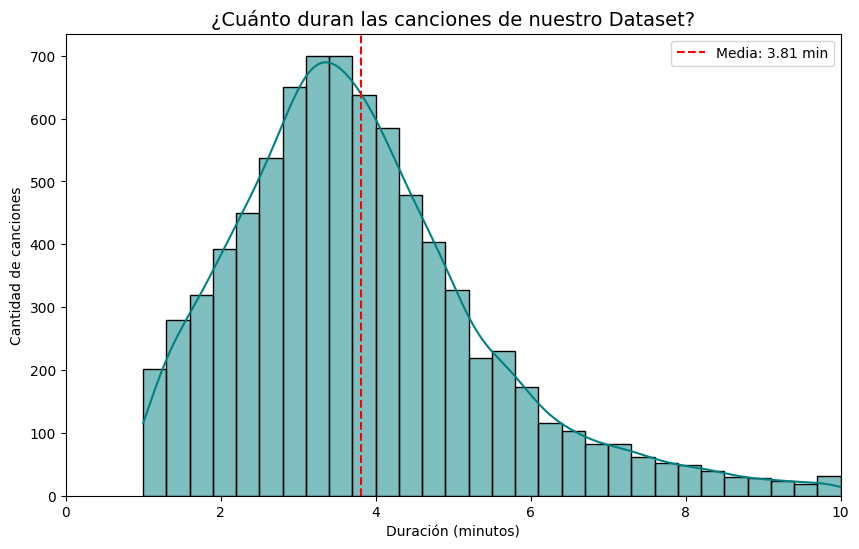

In [ ]:
# DURACIÓN

plt.figure(figsize=(10, 6))

duraciones = tracks_small[('track', 'duration')] / 60

sns.histplot(duraciones, bins=30, kde=True, color='teal')
plt.axvline(duraciones.mean(), color='red', linestyle='--', label=f'Media: {duraciones.mean():.2f} min')

plt.title('¿Cuánto duran las canciones de nuestro Dataset?', fontsize=14)
plt.xlabel('Duración (minutos)')
plt.ylabel('Cantidad de canciones')
plt.legend()
plt.xlim(0, 10)
plt.show()

/tmp/ipykernel_2308/1045223127.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks_small[('track', 'year')] = pd.to_datetime(tracks_small[('track', 'date_created')]).dt.year


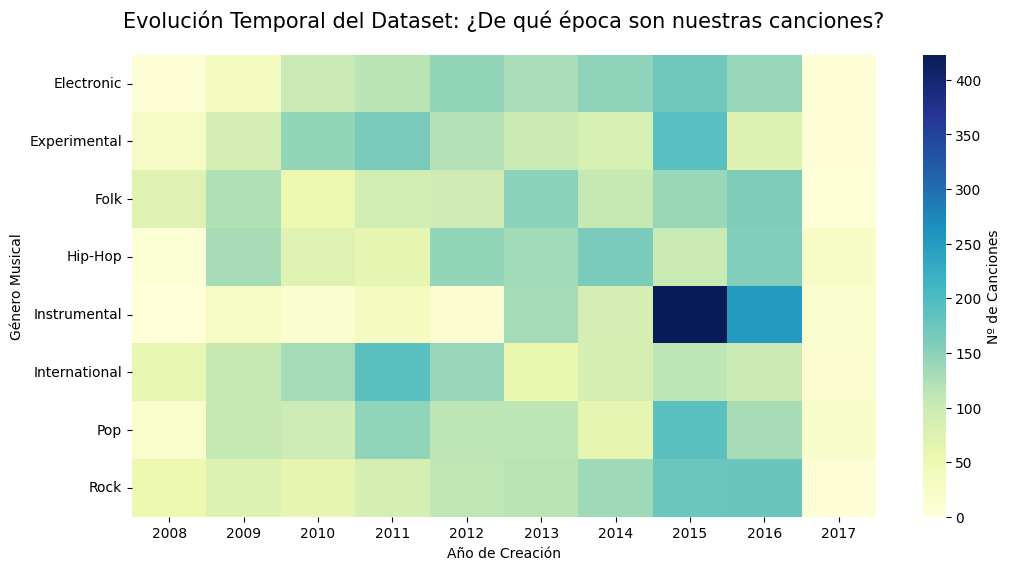

In [ ]:
# FECHA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tracks_small[('track', 'year')] = pd.to_datetime(tracks_small[('track', 'date_created')]).dt.year

timeline = tracks_small.groupby([('track', 'year'), ('track', 'genre_top')]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(timeline.T, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Nº de Canciones'})
plt.title('Evolución Temporal del Dataset: ¿De qué época son nuestras canciones?', fontsize=15, pad=20)
plt.xlabel('Año de Creación')
plt.ylabel('Género Musical')
plt.show()

/tmp/ipykernel_2308/1310447265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Género', y='Energía (RMSE)', palette='viridis', inner="quart")


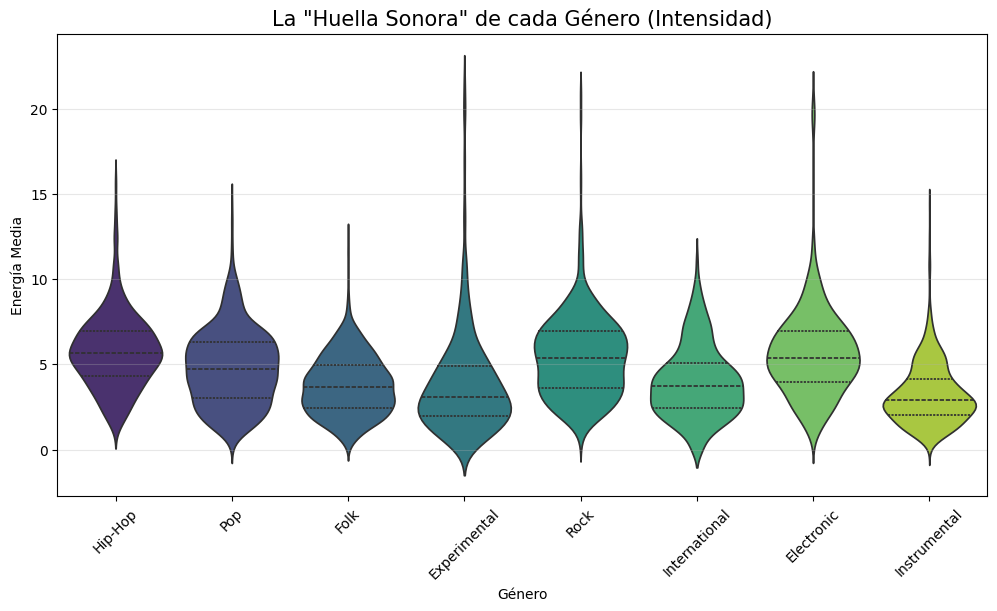

In [ ]:
# VOLUMEN

plt.figure(figsize=(12, 6))

sns.violinplot(data=df_plot, x='Género', y='Energía (RMSE)', palette='viridis', inner="quart")
plt.title('La "Huella Sonora" de cada Género (Intensidad)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Energía Media')
plt.grid(axis='y', alpha=0.3)
plt.show()

Obtención de los Espectogramas


In [ ]:
# Primeras 1100 canciones

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

ruta_fma_small = '/content/drive/MyDrive/ProyectoIA/data/fma_data/fma_small'
ruta_tracks_csv = '/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv'
ruta_destino_espectrogramas = '/content/drive/MyDrive/ProyectoIA/ESPECTROGRAMAS_POR_GENERO'

print("Cargando y filtrando el diccionario de géneros...")
tracks = pd.read_csv(ruta_tracks_csv, index_col=0, header=[0, 1])

subset_small = tracks[tracks[('set', 'subset')] == 'small']

generos_small = subset_small[('track', 'genre_top')].dropna()

print(f"La tabla se ha filtrado. Tenemos {len(generos_small)} canciones en el registro.")

if not os.path.exists(ruta_destino_espectrogramas):
    os.makedirs(ruta_destino_espectrogramas)

def procesar_audio(ruta_mp3, track_id, genero):
    carpeta_genero = os.path.join(ruta_destino_espectrogramas, genero)
    if not os.path.exists(carpeta_genero):
        os.makedirs(carpeta_genero)

    ruta_imagen = os.path.join(carpeta_genero, f"{track_id}.png")
    if os.path.exists(ruta_imagen):
        return

    try:
        y, sr = librosa.load(ruta_mp3, duration=30, sr=22050)

        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

        mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

        plt.figure(figsize=(10, 4))
        plt.axis('off')

        librosa.display.specshow(mel_spect_db, sr=sr, cmap='magma')

        plt.savefig(ruta_imagen, bbox_inches='tight', pad_inches=0)
        plt.close()

    except Exception as e:
        print(f" No se pudo procesar {track_id}: {e}")

print("🚀 Iniciando el procesamiento masivo (esto tomará varias horas)...")
contador = 0

for raiz, carpetas, archivos in os.walk(ruta_fma_small):
    for archivo in archivos:
        if archivo.endswith('.mp3'):
            try:
                track_id = int(archivo.replace('.mp3', ''))

                if track_id in generos_small.index:
                    genero_cancion = generos_small.loc[track_id]
                    ruta_completa_mp3 = os.path.join(raiz, archivo)

                    procesar_audio(ruta_completa_mp3, track_id, genero_cancion)
                    contador += 1

                    if contador % 100 == 0:
                        print(f"🔄 Progreso: {contador} espectrogramas generados...")

            except ValueError:
                pass

print(f"\n🏁 ¡Proceso total completado! Se han generado {contador} espectrogramas.")

Cargando y filtrando el diccionario de géneros...


KeyboardInterrupt: 

In [ ]:
# Segundo intento

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import gc

warnings.filterwarnings('ignore')

print("📖 Cargando diccionario...")
tracks = pd.read_csv(ruta_tracks_csv, index_col=0, header=[0, 1])
generos_small = tracks[tracks[('set', 'subset')] == 'small'][('track', 'genre_top')].dropna()

def procesar_audio(ruta_mp3, track_id, genero):
    carpeta_genero = os.path.join(ruta_destino_espectrogramas, genero)
    if not os.path.exists(carpeta_genero):
        os.makedirs(carpeta_genero)

    ruta_imagen = os.path.join(carpeta_genero, f"{track_id}.png")

    if os.path.exists(ruta_imagen):
        return

    try:
        y, sr = librosa.load(ruta_mp3, duration=30, sr=22050)
        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

        fig = plt.figure(figsize=(10, 4))
        plt.axis('off')
        librosa.display.specshow(mel_spect_db, sr=sr, cmap='magma')
        plt.savefig(ruta_imagen, bbox_inches='tight', pad_inches=0)

        fig.clf()
        plt.close('all')

        del y, sr, mel_spect, mel_spect_db, fig
        gc.collect()

    except Exception as e:
        print(f"⚠️ Error con {track_id}: {e}")

print("🚀 Retomando el procesamiento...")
contador = 0

for raiz, carpetas, archivos in os.walk(ruta_fma_small):
    for archivo in archivos:
        if archivo.endswith('.mp3'):
            try:
                track_id = int(archivo.replace('.mp3', ''))
                if track_id in generos_small.index:
                    genero_cancion = generos_small.loc[track_id]
                    ruta_completa_mp3 = os.path.join(raiz, archivo)

                    procesar_audio(ruta_completa_mp3, track_id, genero_cancion)
                    contador += 1

                    if contador % 100 == 0:
                        print(f"🔄 Progreso desde que le diste a Play: {contador} espectrogramas...")

            except ValueError:
                pass

print("🏁 ¡Proceso terminado con éxito!")

📖 Cargando diccionario...
🚀 Retomando el procesamiento...
🔄 Progreso desde que le diste a Play: 100 espectrogramas...
🔄 Progreso desde que le diste a Play: 200 espectrogramas...
🔄 Progreso desde que le diste a Play: 300 espectrogramas...
🔄 Progreso desde que le diste a Play: 400 espectrogramas...
🔄 Progreso desde que le diste a Play: 500 espectrogramas...
🔄 Progreso desde que le diste a Play: 600 espectrogramas...
🔄 Progreso desde que le diste a Play: 700 espectrogramas...
🔄 Progreso desde que le diste a Play: 800 espectrogramas...
🔄 Progreso desde que le diste a Play: 900 espectrogramas...
🔄 Progreso desde que le diste a Play: 1000 espectrogramas...
🔄 Progreso desde que le diste a Play: 1100 espectrogramas...
🔄 Progreso desde que le diste a Play: 1200 espectrogramas...
🔄 Progreso desde que le diste a Play: 1300 espectrogramas...
🔄 Progreso desde que le diste a Play: 1400 espectrogramas...
🔄 Progreso desde que le diste a Play: 1500 espectrogramas...
🔄 Progreso desde que le diste a Play

Matriz de espectogramas

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

ruta_espectrogramas = '/content/drive/MyDrive/ProyectoIA/ESPECTROGRAMAS_POR_GENERO'

batch_size = 32
img_height = 128
img_width = 256

print("📥 Cargando datos de Entrenamiento (Train)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  ruta_espectrogramas,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("\n📥 Cargando datos de Examen (Validation)...")
val_ds = tf.keras.utils.image_dataset_from_directory(
  ruta_espectrogramas,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

nombres_clases = train_ds.class_names
print(f"\n🎵 ¡Perfecto! Detectadas {len(nombres_clases)} clases: {nombres_clases}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

📥 Cargando datos de Entrenamiento (Train)...
Found 7997 files belonging to 8 classes.
Using 6398 files for training.

📥 Cargando datos de Examen (Validation)...
Found 7997 files belonging to 8 classes.
Using 1599 files for validation.

🎵 ¡Perfecto! Detectadas 8 clases: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


Construcción de Nuestra Red Neuronal

In [ ]:
from tensorflow.keras import layers, models

print("🧠 Construyendo la Red Neuronal Convolucional...")

num_clases = len(nombres_clases)

modelo_cnn = models.Sequential([
    # 1. PREPARACIÓN: Convertimos los colores (0-255) a valores entre 0 y 1
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # 2. EXTRACCIÓN DE CARACTERÍSTICAS (Las Convoluciones)
    # Capa 1: Busca patrones súper básicos
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(), # Reduce la imagen a la mitad quedándose con lo más fuerte

    # Capa 2: Busca patrones más complejos (acordes, ritmos)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Capa 3: Busca conceptos de alto nivel
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 3. TOMA DE DECISIONES
    # Aplanamos la imagen 2D a una fila de números
    layers.Flatten(),

    # Neuronas clásicas que piensan sobre lo que han visto las capas anteriores
    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    # Capa final de salida: 8 neuronas, una por cada género
    layers.Dense(num_clases, activation='softmax')
])

# Compilamos el modelo indicándole cómo debe aprender de sus errores
modelo_cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy', # Esta es la función que se minimiza en el problema de optimización
    metrics = ['accuracy']
    )

# Imprimimos un resumen estructural para vuestro informe
modelo_cnn.summary()

🧠 Construyendo la Red Neuronal Convolucional...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 128, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,048 (16.09 MB)

 Trainable params: 4,219,048 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del Modelo

In [ ]:
import tensorflow as tf
epocas = 10
print(f"🚀 Iniciando entrenamiento por {epocas} épocas. ¡Paciencia, esto usará la GPU!")
with tf.device('/GPU:0'):
  historial = modelo_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epocas,
    verbose = 2
  )
  print("🏁 ¡Entrenamiento de la Red Neuronal completado!")

🚀 Iniciando entrenamiento por 10 épocas. ¡Paciencia, esto usará la GPU!
Epoch 1/10
200/200 - 1479s - 7s/step - accuracy: 0.2473 - loss: 1.9236 - val_accuracy: 0.3765 - val_loss: 1.7150
Epoch 2/10
200/200 - 4s - 19ms/step - accuracy: 0.3417 - loss: 1.7520 - val_accuracy: 0.3565 - val_loss: 1.6778
Epoch 3/10
200/200 - 4s - 20ms/step - accuracy: 0.3825 - loss: 1.6833 - val_accuracy: 0.4321 - val_loss: 1.5732
Epoch 4/10
200/200 - 4s - 19ms/step - accuracy: 0.4023 - loss: 1.6153 - val_accuracy: 0.4528 - val_loss: 1.5283
Epoch 5/10
200/200 - 4s - 18ms/step - accuracy: 0.4308 - loss: 1.5635 - val_accuracy: 0.4259 - val_loss: 1.5462
Epoch 6/10
200/200 - 4s - 19ms/step - accuracy: 0.4473 - loss: 1.5059 - val_accuracy: 0.4634 - val_loss: 1.4756
Epoch 7/10
200/200 - 4s - 19ms/step - accuracy: 0.4814 - loss: 1.4278 - val_accuracy: 0.4878 - val_loss: 1.4382
Epoch 8/10
200/200 - 5s - 25ms/step - accuracy: 0.5170 - loss: 1.3415 - val_accuracy: 0.5122 - val_loss: 1.3966
Epoch 9/10
200/200 - 4s - 19ms/

Guardamos el Modelo

In [ ]:
modelo_cnn.save_weights('/content/drive/MyDrive/ProyectoIA/pesos_cnn_espectrogramas.weights.h5')
print("✅ Pesos guardados como 'pesos_cnn_espectogramas.weights.h5'")

✅ Pesos guardados como 'pesos_cnn_espectogramas.weights.h5'


📊 Evaluando el modelo con métricas avanzadas...
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

📝 REPORTE DE CLASIFICACIÓN (F1-Score):
               precision    recall  f1-score   support

   Electronic       0.43      0.57      0.49       196
 Experimental       0.55      0.39      0.46       209
         Folk       0.50      0.65      0.56       202
      Hip-Hop       0.69      0.56      0.62       212
 Instrumental       0.51      0.53      0.52       199
International       0.58      0.48      0.52       185
          Pop       0.27      0.25      0.26       194
         Rock       0.62      0.66      0.64       202

     accuracy                           0.51      1599
    macro avg       0.52      0.51      0.51      1599
 weighted avg       0.52      0.51      0.51      1599



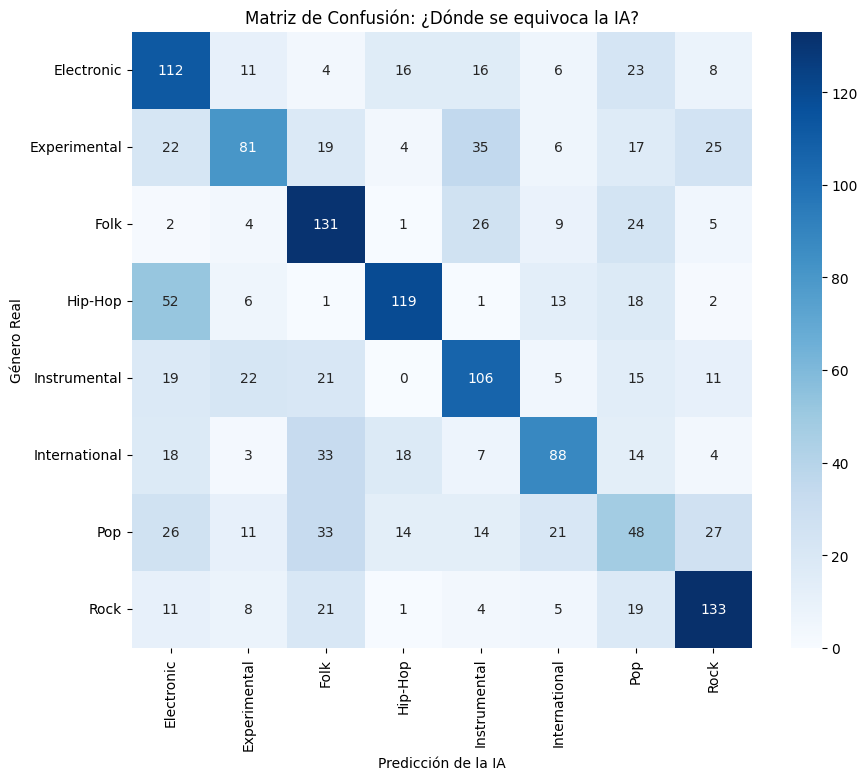

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("📊 Evaluando el modelo con métricas avanzadas...")

# 1. Predicciones vs Realidad
predicciones_prob = modelo_cnn.predict(val_ds)
y_pred = np.argmax(predicciones_prob, axis=1)
y_real = np.concatenate([y for x, y in val_ds], axis=0)

# 2. Reporte Numérico (F1-Score)
print("\n📝 REPORTE DE CLASIFICACIÓN (F1-Score):")
print(classification_report(y_real, y_pred, target_names=nombres_clases))

# 3. Matriz de Confusión Visual
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_real, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión: ¿Dónde se equivoca la IA?')
plt.xlabel('Predicción de la IA')
plt.ylabel('Género Real')
plt.show()

Predicción de resultados

🔍 Analizando: /content/drive/MyDrive/ProyectoIA/The_Fog_Trey_Xavier_Rod_Kim.mp3

✅ Resultado: Este audio suena a **International**
📊 Confianza: 26.22%


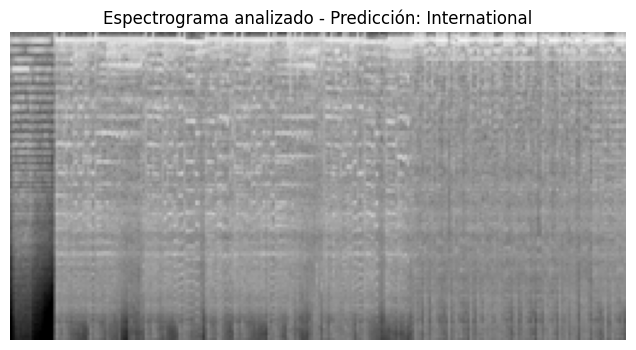

In [ ]:
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
# Obtenemos la versión reducida de features.csv
ruta_audio = '/content/drive/MyDrive/ProyectoIA/The_Fog_Trey_Xavier_Rod_Kim.mp3'
img_height = 128
img_width = 256

def predecir_genero(ruta_archivo):
    print(f"🔍 Analizando: {ruta_archivo}")

    # 1. CARGAR AUDIO Y CONVERTIR A ESPECTROGRAMA
    # Cargamos solo los primeros 30 segundos para ser rápidos
    y, sr = librosa.load(ruta_archivo, duration=30)

    # Creamos el espectrograma de Mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # 2. CONVERTIR ESPECTROGRAMA A IMAGEN COMPATIBLE
    # Normalizamos los valores para que queden entre 0 y 255 (formato imagen)
    img_array = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min()) * 255
    img_array = img_array.astype(np.uint8)

    # Convertimos a imagen y redimensionamos al tamaño que espera tu modelo
    img_pil = Image.fromarray(img_array).convert('RGB')
    img_pil = img_pil.resize((img_width, img_height))

    # Convertimos a array de numpy y añadimos la dimensión del batch (1, 128, 256, 3)
    input_arr = tf.keras.utils.img_to_array(img_pil)
    input_arr = np.array([input_arr])

    # 3. REALIZAR LA PREDICCIÓN
    predicciones = modelo_cnn.predict(input_arr, verbose=0)
    score = tf.nn.softmax(predicciones[0]) # Convertimos a probabilidades

    # 4. MOSTRAR RESULTADOS
    clase_predicha = nombres_clases[np.argmax(score)]
    confianza = 100 * np.max(score)

    print(f"\n✅ Resultado: Este audio suena a **{clase_predicha}**")
    print(f"📊 Confianza: {confianza:.2f}%")

    # Opcional: Mostrar el espectrograma que la IA está viendo
    plt.figure(figsize=(10, 4))
    plt.imshow(img_pil)
    plt.title(f"Espectrograma analizado - Predicción: {clase_predicha}")
    plt.axis('off')
    plt.show()

# Ejecutar la función
predecir_genero(ruta_audio)